# ML Fundamentals: Linear Regression

## 1. Introduction

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values. It models the relationship between input features and a target variable by fitting a straight-line equation that minimizes prediction error.

In this project, we will use the California Housing dataset to predict median house values based on housing and location-related features.

## 2. Objective

The objective of this project is to build and evaluate a Linear Regression model while understanding the complete machine learning workflow:

- Loading the dataset
- Exploring the data
- Understanding feature relationships
- Training a Linear Regression model
- Evaluating model performance
- Interpreting results

In [20]:
print("Notebook is working")

Notebook is working


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 3. Loading the Dataset

The California Housing dataset is a widely used benchmark dataset for regression problems. It contains information about housing districts in California, where each row represents a district and the target variable is the median house value.

The dataset consists of eight numerical input features describing demographic and housing characteristics.

In [22]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Understanding the Dataset

Before building a machine learning model, it is important to understand the structure and quality of the dataset.

In this section, we will examine:

- Number of rows and columns
- Feature names
- Data types
- Missing values
- Basic statistical summary

This helps identify potential preprocessing steps and provides a better understanding of the data.

In [23]:
df.shape

(20640, 9)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [26]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Insights

From the initial exploration of the dataset, we observe the following:

- The dataset contains **20,640 observations** and **9 columns**, consisting of **8 input features** and **1 target variable (`MedHouseVal`)**.
- All features are numerical, making the dataset directly suitable for Linear Regression without categorical encoding.
- No missing values are present in any of the columns, eliminating the need for missing value imputation.
- The descriptive statistics reveal noticeable variation in feature scales. For example, `Population` ranges from a few individuals to tens of thousands, while `Latitude` and `Longitude` have much smaller ranges. This difference in scale will be considered during preprocessing.
- The target variable, `MedHouseVal`, represents the median house value and will be predicted using the remaining housing-related features.

Overall, the dataset is clean, well-structured, and appropriate for building a Linear Regression model.

## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the distribution of the data, identify patterns, detect anomalies, and examine relationships between features before building a machine learning model.

In this section, we will visualize the dataset to gain meaningful insights that can improve model understanding and interpretation.

In [57]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


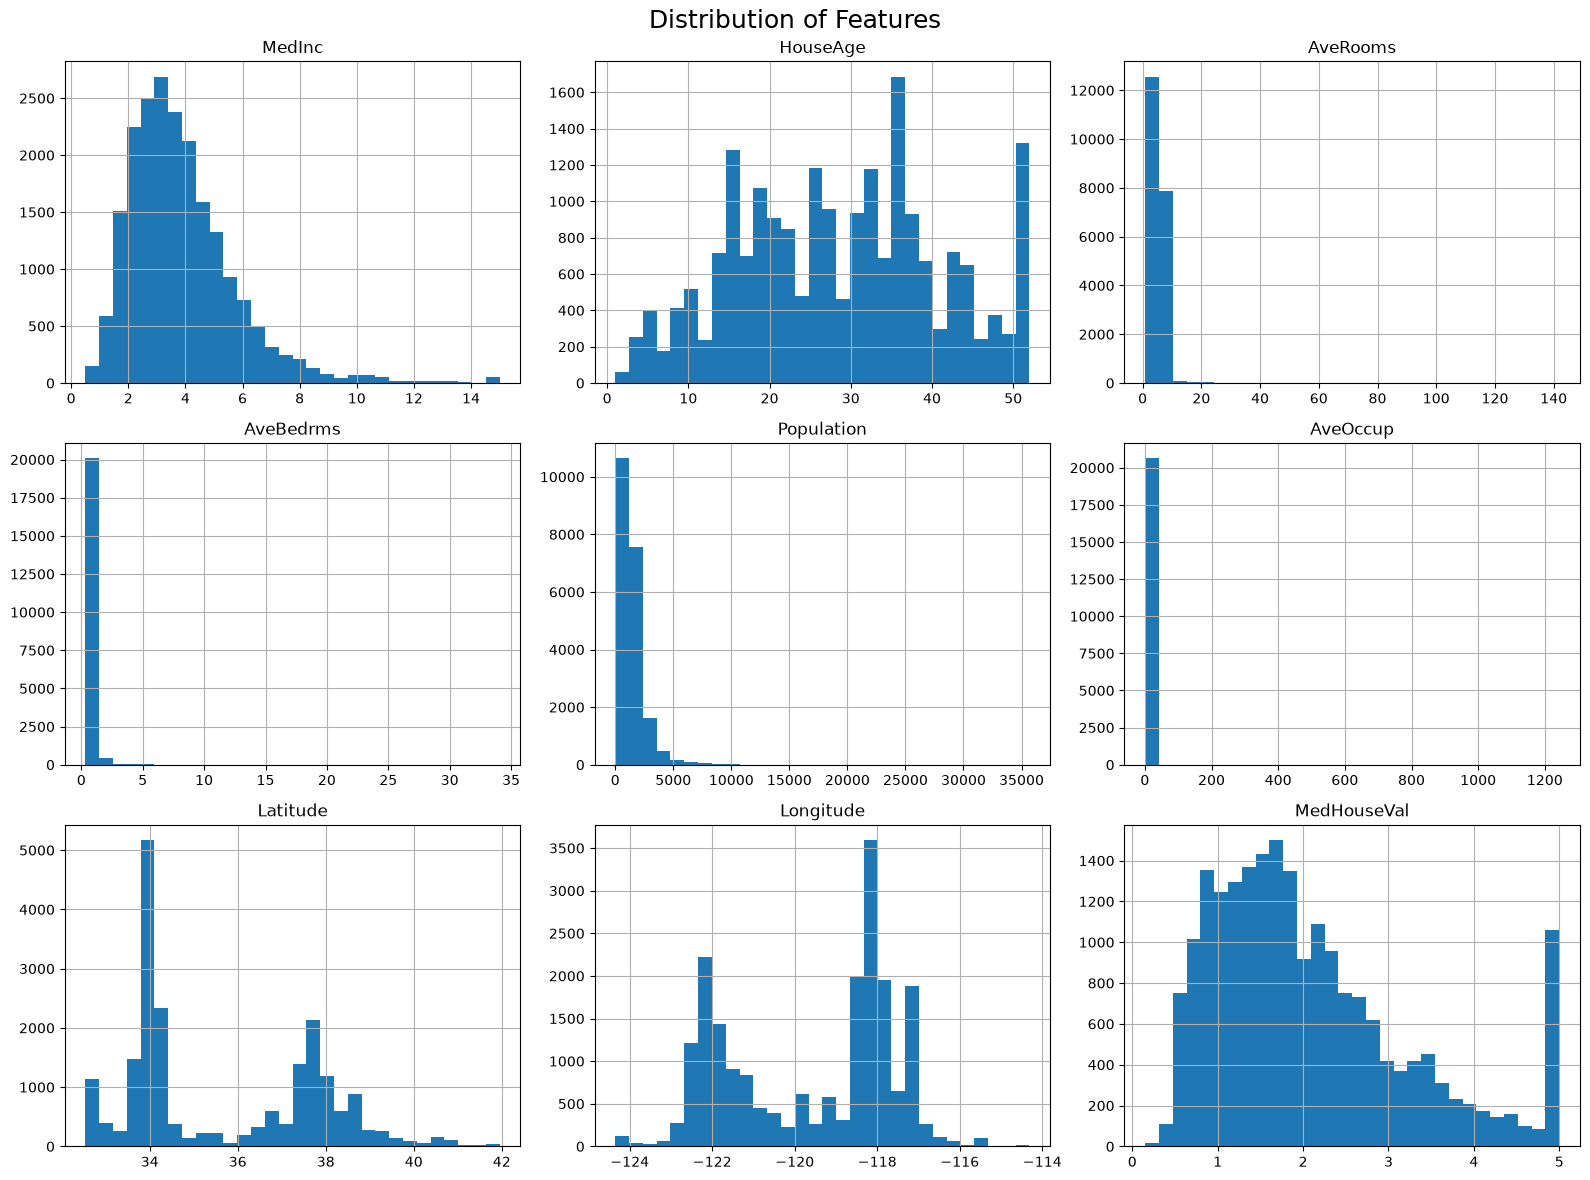

In [58]:
df.hist(figsize=(16, 12), bins=30)

plt.suptitle("Distribution of Features", fontsize=18)

plt.tight_layout()

plt.show()

### Insights

The feature distributions provide several important observations:

- Most features exhibit different distribution patterns rather than following a perfect normal distribution.
- Features such as **Median Income (`MedInc`)** are positively skewed, indicating that higher-income districts are relatively less common.
- Population-related features show a wide spread, suggesting significant variation among districts.
- The target variable **Median House Value (`MedHouseVal`)** appears to be capped at an upper limit, which is a known characteristic of this dataset.
- Understanding these distributions helps determine whether transformations or feature scaling may be beneficial during model development.

### 5.1 Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between variables. It helps identify which features are most strongly associated with the target variable and reveals relationships among predictor variables.

Understanding these correlations provides valuable insight before training a Linear Regression model.

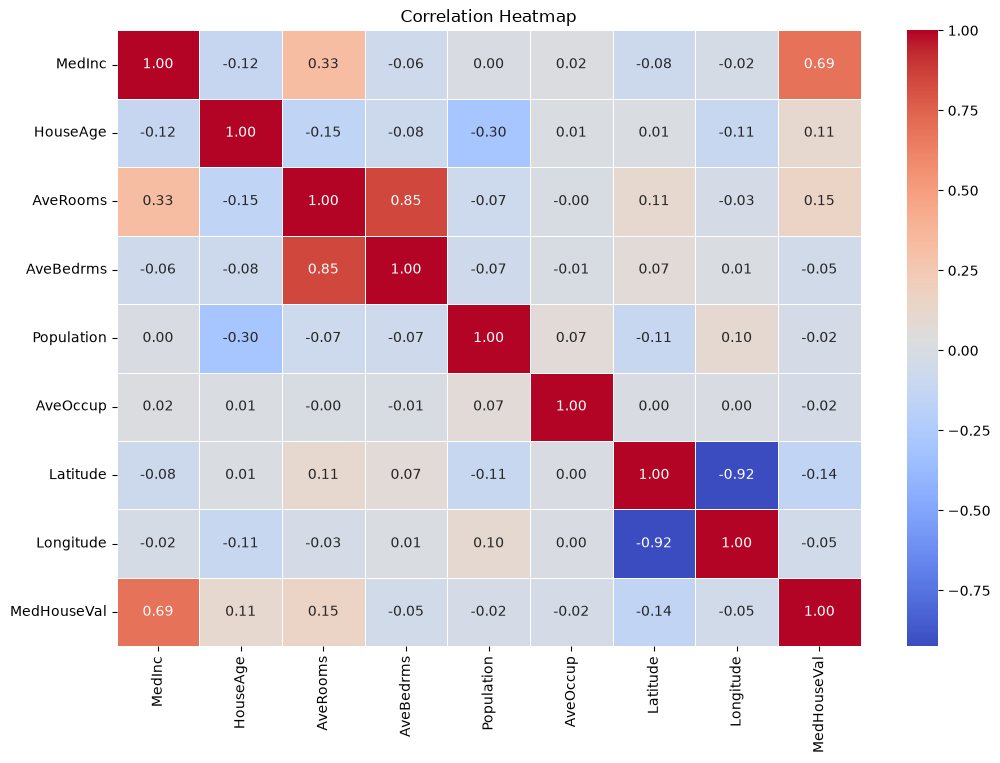

In [59]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Insights

The correlation heatmap reveals several important relationships within the dataset:

- **Median Income (`MedInc`)** has the strongest positive correlation with the target variable (`MedHouseVal`), making it one of the most influential predictors.
- Geographic features such as **Latitude** and **Longitude** also exhibit noticeable relationships with house values, indicating that location plays an important role in property pricing.
- Most predictor variables are not highly correlated with one another, suggesting limited multicollinearity.
- Understanding these relationships helps identify influential features while ensuring that the assumptions of Linear Regression are not severely violated.

### 5.2 Feature Relationships

Understanding how individual features relate to the target variable helps identify important predictors and provides intuition about the behavior of the dataset.

The following visualizations compare the strongest predictor with the target variable and examine the geographical distribution of house prices.

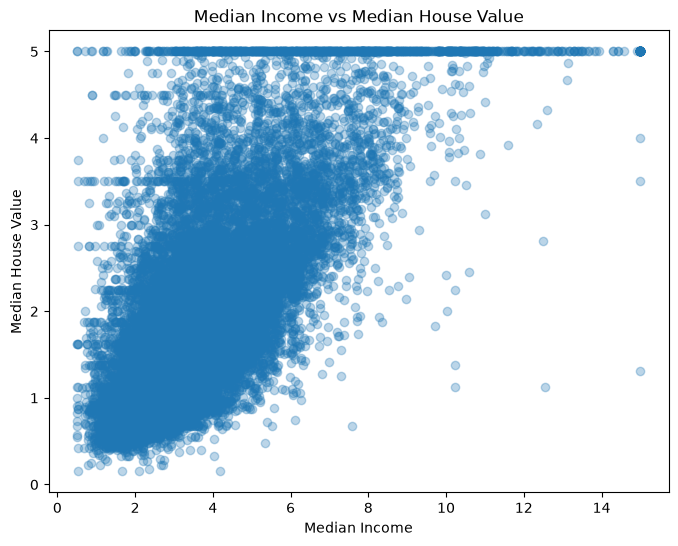

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

### Insights

The scatter plot indicates a clear positive relationship between median income and median house value.

- Districts with higher median incomes generally have higher house values.
- The relationship is approximately linear, making Median Income a strong predictor for Linear Regression.
- A few scattered observations indicate variability caused by other influencing factors such as location and demographics.

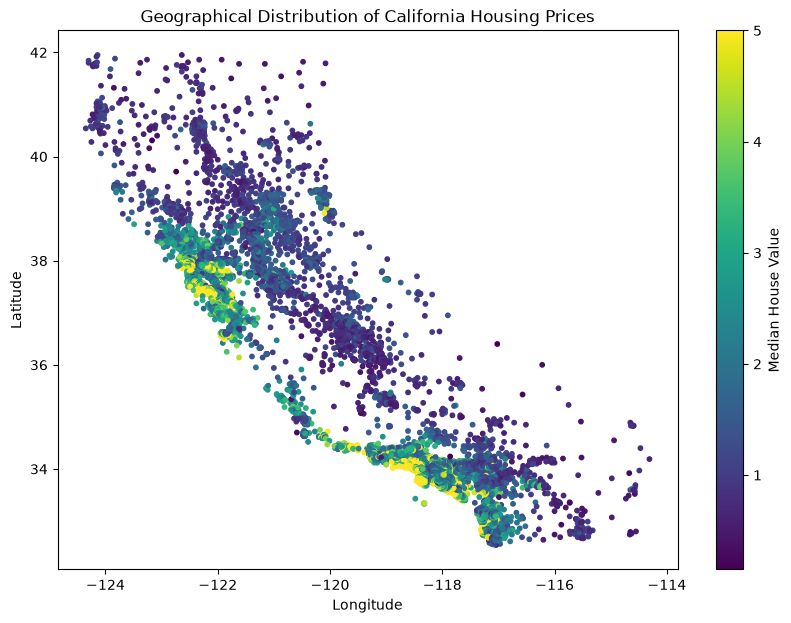

In [61]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="viridis",
    s=10
)

plt.colorbar(label="Median House Value")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of California Housing Prices")

plt.show()

### Insights

The geographical distribution highlights the influence of location on housing prices.

- House values vary considerably across different regions of California.
- Coastal areas generally exhibit higher property values compared to inland regions.
- This suggests that geographical features such as latitude and longitude contribute significantly to predicting house prices.

### 5.3 Relationship Between Features

Pairwise relationships between features help identify trends, potential multicollinearity, and how variables interact with each other.

To keep the visualization readable, we will examine a subset of the most important features.

### 6.1 Train-Test Split

To evaluate the model fairly, the dataset is divided into two subsets:

- **Training Set (80%)**: Used to train the Linear Regression model.
- **Testing Set (20%)**: Used to evaluate the model on unseen data.

Using a separate testing dataset helps estimate how well the model generalizes to new data.

In [63]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape :", X.shape)
print("Target shape   :", y.shape)

Features shape : (20640, 8)
Target shape   : (20640,)


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (16512, 8)
Testing Features  : (4128, 8)
Training Target   : (16512,)
Testing Target    : (4128,)


# 7. Model Training

Linear Regression learns the relationship between the input features and the target variable by fitting the best possible linear equation to the training data.

The trained model will then be used to predict house values for unseen data.

In [66]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Insights

The Linear Regression model has been successfully trained using the training dataset.

During training, the algorithm estimates the optimal coefficients for each feature such that the prediction error is minimized. These learned coefficients represent the contribution of each feature toward predicting the median house value.

# 8. Model Prediction

After training, the model is used to generate predictions on the testing dataset. These predictions will later be compared with the actual values to evaluate the model's performance.

In [67]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725,
       2.01175367, 2.64550005, 2.16875532, 2.74074644, 3.91561473])

# 9. Model Evaluation

Model evaluation helps us understand how well the Linear Regression model performs on unseen data.

For regression problems, common evaluation metrics include:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [75]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,0.533200
1,MSE,0.555892
2,RMSE,0.745581
3,R2 Score,0.575788


## 9.1 Actual vs Predicted Values

A scatter plot comparing the actual house values with the predicted values helps us visually assess the model's performance.

If the model predicts perfectly, all points would lie exactly on the diagonal line.

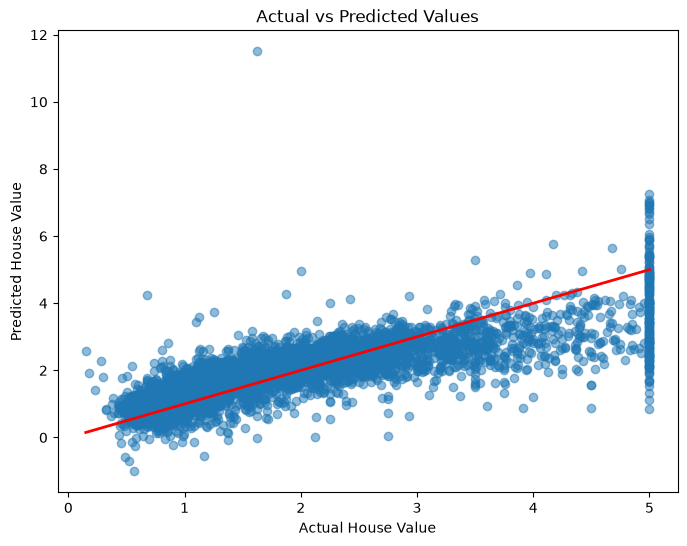

In [76]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")

plt.show()

### Insights

- Most predictions follow the general trend of the actual values, indicating that the model captures the underlying relationship reasonably well.
- The spread around the diagonal line represents prediction errors.
- Larger deviations indicate observations where the model struggles to accurately estimate the house value.

## 9.2 Residual Analysis

Residuals represent the difference between the actual and predicted values.

Analyzing residuals helps determine whether the Linear Regression assumptions are reasonably satisfied and whether systematic prediction errors exist.

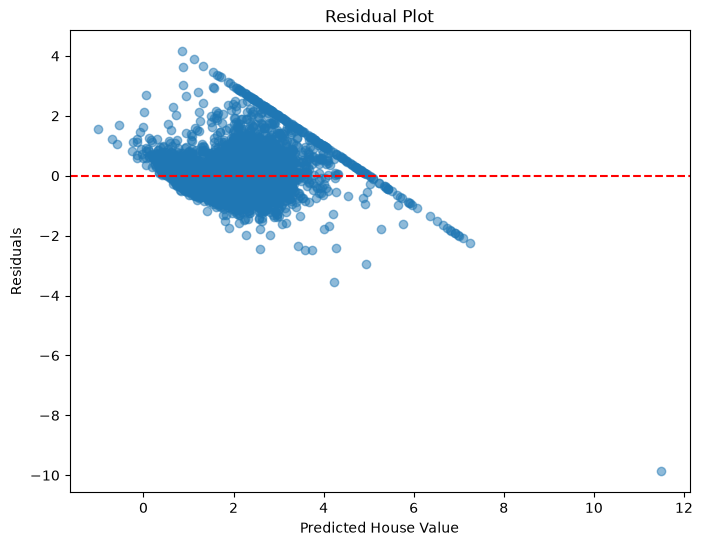

In [77]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## 9.3 Feature Importance

In Linear Regression, each feature is assigned a coefficient that represents its influence on the target variable.

- A positive coefficient indicates that an increase in the feature tends to increase the predicted house value.
- A negative coefficient indicates an inverse relationship.
- The magnitude of the coefficient reflects the strength of the relationship, assuming all other features remain constant.

In [80]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coefficients

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
7,Longitude,-0.433708
6,Latitude,-0.419792
2,AveRooms,-0.123323
1,HouseAge,0.009724
5,AveOccup,-0.003526
4,Population,-0.000002


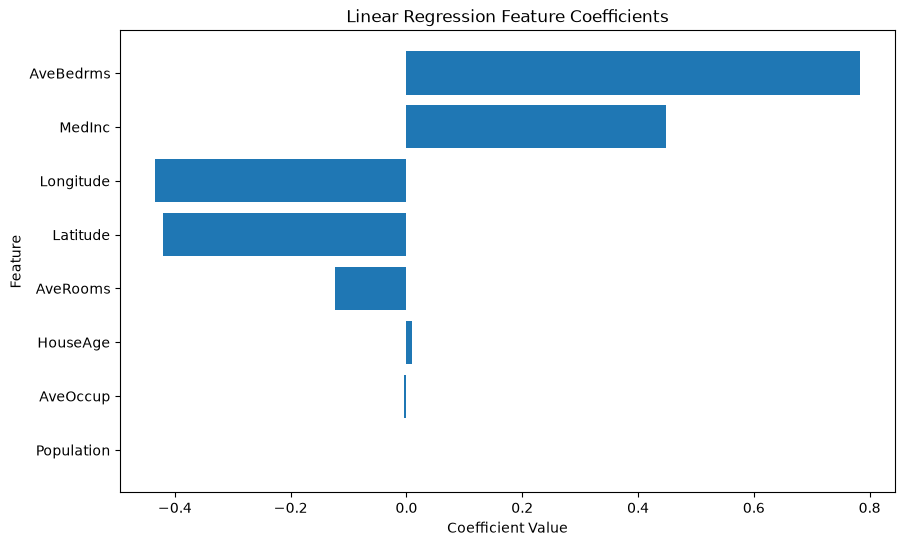

In [81]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Feature Coefficients")

plt.gca().invert_yaxis()

plt.show()

### Insights

The feature coefficients indicate how each predictor contributes to the model's predictions.

- Features with larger absolute coefficient values have a stronger influence on the predicted house value.
- Positive coefficients increase the predicted value, whereas negative coefficients decrease it.
- Coefficient interpretation should always consider feature scales and potential interactions among variables.

# 10. Conclusion

In this project, a Linear Regression model was successfully developed using the California Housing dataset.

The project covered the complete machine learning workflow, including:

- Data loading
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Train-test splitting
- Model training
- Prediction
- Model evaluation
- Residual analysis
- Feature interpretation

The model demonstrated the ability to capture the relationship between housing characteristics and median house values while providing a solid foundation for understanding regression-based machine learning algorithms.

Future improvements may include feature scaling, polynomial regression, regularization techniques (Ridge and Lasso), and hyperparameter optimization to further enhance predictive performance.

# 11. Saving the Model

Once the model has been trained and evaluated, it is saved to disk so that it can be reused later for making predictions without retraining.

In [84]:
import os

print(os.getcwd())
print(os.listdir())

/workspaces/ml-linear-regression
['notebook.ipynb', 'requirements.txt', 'README.md', 'src', '.git']


In [85]:
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Folders created.")

Folders created.


In [86]:
metrics.to_csv("outputs/metrics.csv", index=False)

coefficients.to_csv("outputs/coefficients.csv", index=False)

print("Evaluation metrics and coefficients saved.")

Evaluation metrics and coefficients saved.


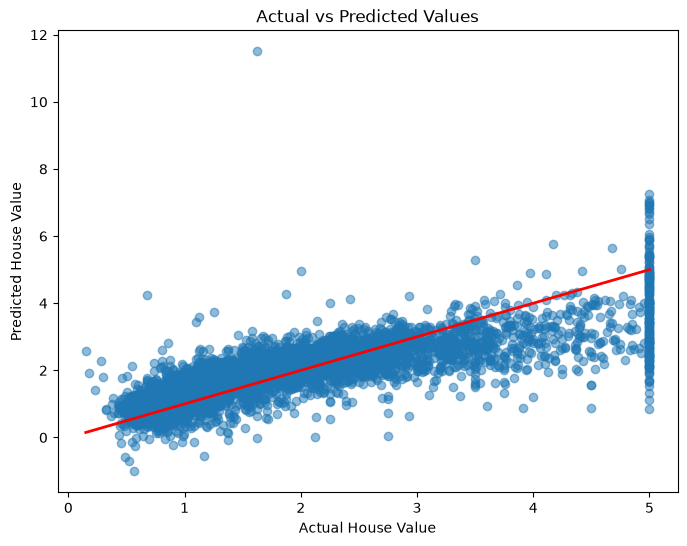

In [87]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")

plt.savefig("outputs/actual_vs_predicted.png", dpi=300)

plt.show()

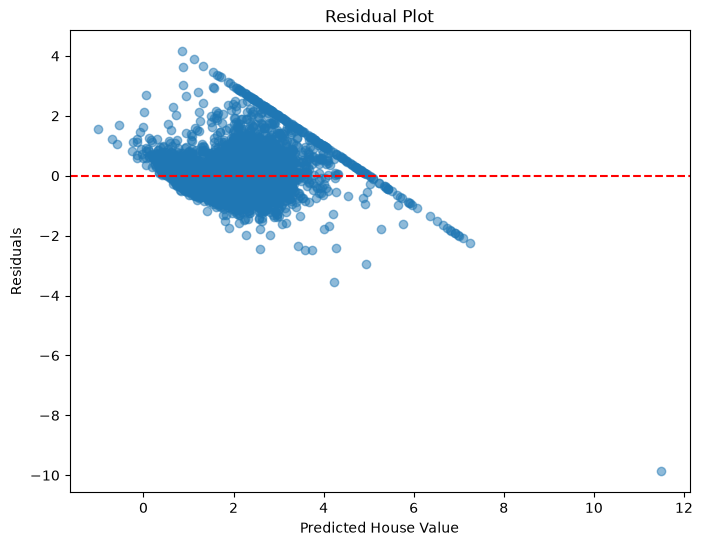

In [88]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig("outputs/residual_plot.png", dpi=300)

plt.show()

In [89]:
import os

print("Models:", os.listdir("models"))
print("Outputs:", os.listdir("outputs"))

Models: []
Outputs: ['actual_vs_predicted.png', 'residual_plot.png', 'metrics.csv', 'coefficients.csv']
